<a href="https://colab.research.google.com/github/b23cm1024/Fast_Sam_DL_Project/blob/main/Lab_PixelRNN_PixelCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Autoregressive Image Generation with PixelCNN & PixelRNN

---

**Objective:** Understand how **autoregressive models** generate images one pixel at a time by modelling the joint distribution as a product of conditionals. We implement both **PixelCNN** (masked convolutions) and **PixelRNN** (Row LSTM), train them on MNIST, compare their outputs, and explore unique capabilities like image completion.


**Why autoregressive models?**  VAEs and GANs learn to generate images in one shot, but autoregressive models take a fundamentally different approach: they decompose the image distribution using the **chain rule of probability** and generate each pixel conditioned on all previously generated pixels. This gives them tractable, exact likelihoods, something VAEs approximate and GANs lack entirely.

## Part 0 : Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

# Load MNIST - we binarise images (pixel is 0 or 1) to keep things simple.
# This lets us use a Bernoulli likelihood and binary cross-entropy loss.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())   # binarise
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Unique pixel values after binarisation: {torch.unique(train_dataset[0][0]).tolist()}")

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

Training samples: 60000, Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Unique pixel values after binarisation: [0.0, 1.0]


---
## Part 1 : The Autoregressive Idea

### 1.1 Chain Rule Factorisation

Any joint distribution over $n$ pixels can be written exactly as:

$$p(\mathbf{x}) = \prod_{i=1}^{n} p(x_i \mid x_1, x_2, \dots, x_{i-1})$$

This is not an approximation, it is the chain rule of probability. The challenge is modelling each conditional $p(x_i \mid x_{<i})$ efficiently.

We scan pixels in **raster order** (left to right, top to bottom), so pixel $i$ depends only on pixels above it and to its left:

```
  Context for pixel * (raster order):

  # # # # #
  # # # # #
  # # * . .
  . . . . .
  . . . . .

  # = available context    . = future (not available)
```

### 1.2 Two Approaches

| | **PixelRNN** | **PixelCNN** |
|---|---|---|
| **Architecture** | Row LSTM / Diagonal BiLSTM processes pixels with recurrent state | Masked convolutions process all positions in parallel |
| **Receptive field** | Entire available context via hidden state | Grows with network depth (stacked convolutions) |
| **Training speed** | Slower due to sequential row processing | Fast, fully convolutional, parallelisable |
| **Generation speed** | Both are slow: pixel-by-pixel, $O(n)$ forward passes |
| **Log-likelihood** | Slightly better (richer context modelling) | Slightly worse but faster to train |

---
## Part 2 : Masked Convolutions (PixelCNN Foundation)

### 2.1 Why Masking?

A standard 2D convolution at position $(r, c)$ reads from a symmetric neighbourhood, including pixels to the right of and below $(r, c)$. This violates the autoregressive constraint because those are *future* pixels.

**Masked convolutions** zero out the filter weights that correspond to future positions, enforcing the causal ordering.

### 2.2 Type A vs Type B Masks

For a $k \times k$ kernel centered at $(r, c)$:

- **Mask A** (first layer only): all rows above center are **1**, center row positions left of center are **1**, center position itself is **0**, everything else is **0**.
- **Mask B** (all subsequent layers): same as A, but center position is **1**.

Mask A prevents the network from seeing the *current* pixel's ground truth as input (it would trivially learn to copy). Mask B in deeper layers is safe because those features are already derived from past pixels only.

Let's build and visualise both masks.

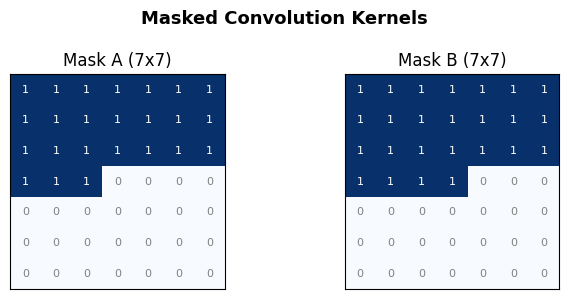

Mask A: center pixel is 0 -> first layer cannot see current pixel
Mask B: center pixel is 1 -> deeper layers can use their own feature (already causal)


In [ ]:
class MaskedConv2d(nn.Conv2d):
    """
    A Conv2d where future-pixel weights are permanently zeroed.
    mask_type: 'A' for the first layer, 'B' for all subsequent layers.
    """
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ('A', 'B'), "mask_type must be 'A' or 'B'"
        self.mask_type = mask_type

        # Register mask as a buffer (not a parameter, no gradients)
        self.register_buffer('mask', torch.ones_like(self.weight))

        _, _, kH, kW = self.weight.shape
        # Zero out the bottom half
        self.mask[:, :, kH // 2 + 1:, :] = 0
        # Zero out the right half of the center row
        self.mask[:, :, kH // 2, kW // 2 + 1:] = 0
        # For type A, also zero the center pixel
        if mask_type == 'A':
            self.mask[:, :, kH // 2, kW // 2] = 0

    def forward(self, x):
        # Apply mask before convolution
        self.weight.data *= self.mask
        return super().forward(x)


# --- Visualise the masks ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for i, mtype in enumerate(['A', 'B']):
    layer = MaskedConv2d(mtype, in_channels=1, out_channels=1,
                         kernel_size=7, padding=3)
    mask_2d = layer.mask[0, 0].cpu().numpy()
    axes[i].imshow(mask_2d, cmap='Blues', vmin=0, vmax=1)
    axes[i].set_title(f'Mask {mtype} (7x7)', fontsize=12)
    for r in range(mask_2d.shape[0]):
        for c in range(mask_2d.shape[1]):
            axes[i].text(c, r, int(mask_2d[r, c]),
                        ha='center', va='center', fontsize=8,
                        color='white' if mask_2d[r, c] == 1 else 'gray')
    axes[i].set_xticks([]); axes[i].set_yticks([])
plt.suptitle('Masked Convolution Kernels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Mask A: center pixel is 0 -> first layer cannot see current pixel")
print("Mask B: center pixel is 1 -> deeper layers can use their own feature (already causal)")

---
## Part 3 : PixelCNN

### 3.1 Architecture

1. **Input layer:** Mask-A convolution (7x7) to establish the causal constraint.
2. **Hidden layers:** Several Mask-B convolutions (7x7) with ReLU to deepen the receptive field.
3. **Output layer:** 1x1 convolution followed by sigmoid to predict $p(x_i = 1 \mid x_{<i})$ per pixel.

### 3.2 Loss Function

Since our images are binary, each pixel is modelled as a Bernoulli random variable. The negative log-likelihood is the **binary cross-entropy**:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \Big[ x_i \log \hat{p}_i + (1 - x_i) \log(1 - \hat{p}_i) \Big]$$

where $\hat{p}_i$ is the model's predicted probability for pixel $i$ being 1.

In [ ]:
class PixelCNN(nn.Module):
    def __init__(self, n_channels=64, n_layers=7, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2

        layers = []
        # First layer: Mask A
        layers.append(MaskedConv2d('A', in_channels=1, out_channels=n_channels,
                                   kernel_size=kernel_size, padding=padding))
        layers.append(nn.BatchNorm2d(n_channels))
        layers.append(nn.ReLU(True))

        # Hidden layers: Mask B
        for _ in range(n_layers - 1):
            layers.append(MaskedConv2d('B', in_channels=n_channels,
                                       out_channels=n_channels,
                                       kernel_size=kernel_size, padding=padding))
            layers.append(nn.BatchNorm2d(n_channels))
            layers.append(nn.ReLU(True))

        # Output layer: 1x1 conv to single channel probability
        layers.append(nn.Conv2d(n_channels, 1, kernel_size=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """Returns logits (pre-sigmoid) for each pixel."""
        return self.net(x)


pixelcnn = PixelCNN(n_channels=64, n_layers=7).to(device)

total_params = sum(p.numel() for p in pixelcnn.parameters())
print(f"PixelCNN parameters: {total_params:,}")
print(f"\nArchitecture:\n{pixelcnn}")

PixelCNN parameters: 1,208,769

Architecture:
PixelCNN(
  (net): Sequential(
    (0): MaskedConv2d(1, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.

### 3.3 Training PixelCNN

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    """Generic training loop for any model that outputs logits."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(1, epochs + 1):
        # --- Train ---
        model.train()
        epoch_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            logits = model(images)
            loss = F.binary_cross_entropy_with_logits(logits, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * images.size(0)

        train_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # --- Evaluate ---
        model.eval()
        epoch_loss = 0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                logits = model(images)
                loss = F.binary_cross_entropy_with_logits(logits, images)
                epoch_loss += loss.item() * images.size(0)
        test_loss = epoch_loss / len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f"Epoch {epoch:2d}/{epochs}  |  Train NLL: {train_loss:.4f}  |  Test NLL: {test_loss:.4f}")

    return train_losses, test_losses


print("Training PixelCNN...")
cnn_train_losses, cnn_test_losses = train_model(pixelcnn, train_loader, test_loader, epochs=10)

Training PixelCNN...
Epoch  1/10  |  Train NLL: 0.1733  |  Test NLL: 0.0852
Epoch  2/10  |  Train NLL: 0.0825  |  Test NLL: 0.0806
Epoch  3/10  |  Train NLL: 0.0790  |  Test NLL: 0.0827
Epoch  4/10  |  Train NLL: 0.0775  |  Test NLL: 0.0769
Epoch  5/10  |  Train NLL: 0.0763  |  Test NLL: 0.0772
Epoch  6/10  |  Train NLL: 0.0756  |  Test NLL: 0.0760
Epoch  7/10  |  Train NLL: 0.0749  |  Test NLL: 0.0753
Epoch  8/10  |  Train NLL: 0.0745  |  Test NLL: 0.0758
Epoch  9/10  |  Train NLL: 0.0741  |  Test NLL: 0.0745
Epoch 10/10  |  Train NLL: 0.0738  |  Test NLL: 0.0742


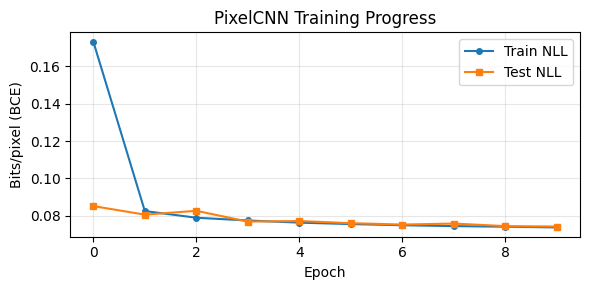

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(cnn_train_losses, label='Train NLL', marker='o', markersize=4)
plt.plot(cnn_test_losses, label='Test NLL', marker='s', markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Bits/pixel (BCE)')
plt.title('PixelCNN Training Progress')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 4 : PixelRNN (Row LSTM)

### 4.1 From Convolutions to Recurrence

PixelCNN's receptive field is limited by the depth of stacked convolutions. PixelRNN replaces these with recurrent units that carry information across the entire image.

The **Row LSTM** variant (from [van den Oord et al., 2016](https://arxiv.org/abs/1601.06759)) works as follows:

1. Use a masked convolution to compute input features for each row.
2. Process each row with an LSTM that receives the hidden state from the row above.
3. This gives each pixel access to a roughly triangular receptive field covering all previous rows.

### 4.2 Architecture

Our implementation:
1. **Input convolution:** Mask-A convolution to extract causal features.
2. 2. **Row LSTM layers:** Process features row-by-row, top to bottom. The input-to-gate convolution within each row must be **causal** (left-padded only), otherwise position $c$ peeks at features from position $c+1$, which encode information about pixel $c$ itself (since the Mask-A conv includes left neighbours as context). The hidden-to-gate convolution can use standard padding because the hidden state comes entirely from the row above, which is all past in raster order.
3. **Output layer:** 1x1 convolution to predict per-pixel Bernoulli probabilities.

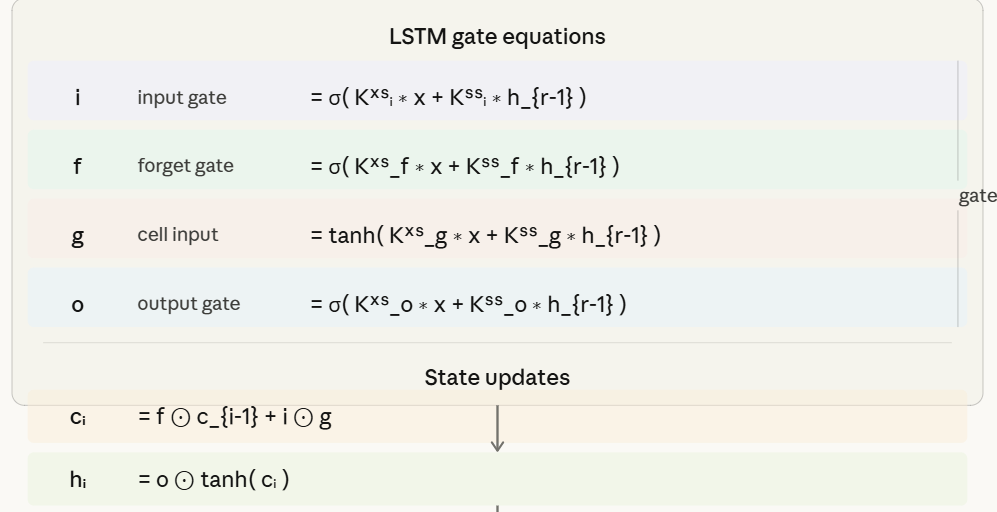

In [ ]:
class CausalConv1d(nn.Module):
    """1D conv that only looks left, never right."""
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.pad = kernel_size - 1
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=0)

    def forward(self, x):
        x = F.pad(x, (self.pad, 0))
        return self.conv(x)

class RowLSTMLayer(nn.Module):
    """
    Row LSTM: processes the image row-by-row from top to bottom.
    Each row's LSTM receives context from the row above via hidden state.
    Uses 1D convolutions along each row for the LSTM gates.
    """
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.hidden_channels = hidden_channels

        # Input-to-gate: convolve across the row
        self.i2g = CausalConv1d(in_channels, 4 * hidden_channels, kernel_size=3)
        # Hidden-to-gate: convolve across the row (from row above)
        self.h2g = nn.Conv1d(hidden_channels, 4 * hidden_channels, kernel_size=3, padding=1)
#At each iteration, **all 28 positions in the row are computed in parallel** via the 1D convolutions.
#Only the row loop is sequential (because each row needs `h` from the row above)
    def forward(self, x):
        """
        x: (B, C, H, W) - input feature map
        Returns: (B, hidden_channels, H, W) - output feature map
        """
        B, C, H, W = x.shape
        h = torch.zeros(B, self.hidden_channels, W, device=x.device)
        c = torch.zeros(B, self.hidden_channels, W, device=x.device)

        output = []
        for row in range(H):
            x_row = x[:, :, row, :]                  # (B, C, W)
            gates = self.i2g(x_row) + self.h2g(h)    # (B, 4*H_c, W)

            i, f, o, g = gates.chunk(4, dim=1)
            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            o = torch.sigmoid(o)
            g = torch.tanh(g)

            c = f * c + i * g
            h = o * torch.tanh(c)
            output.append(h)

        # Stack rows back into (B, hidden_channels, H, W)
        return torch.stack(output, dim=2)


class PixelRNN(nn.Module):
    def __init__(self, hidden_channels=32, n_lstm_layers=3, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2

        # Input: Mask-A convolution (same causal constraint as PixelCNN)
        self.input_conv = MaskedConv2d('A', in_channels=1, out_channels=hidden_channels,
                                       kernel_size=kernel_size, padding=padding)
        self.input_bn = nn.BatchNorm2d(hidden_channels)

        # Stack of Row LSTM layers
        self.lstm_layers = nn.ModuleList()
        self.lstm_bns = nn.ModuleList()
        for _ in range(n_lstm_layers):
            self.lstm_layers.append(RowLSTMLayer(hidden_channels, hidden_channels))
            self.lstm_bns.append(nn.BatchNorm2d(hidden_channels))

        # Output: 1x1 conv
        self.output_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)

    def forward(self, x):
        h = F.relu(self.input_bn(self.input_conv(x)))
        for lstm, bn in zip(self.lstm_layers, self.lstm_bns):
            h = F.relu(bn(lstm(h)))
        return self.output_conv(h)


pixelrnn = PixelRNN(hidden_channels=32, n_lstm_layers=3).to(device)

total_params = sum(p.numel() for p in pixelrnn.parameters())
print(f"PixelRNN parameters: {total_params:,}")
print(f"\nArchitecture:\n{pixelrnn}")

PixelRNN parameters: 76,385

Architecture:
PixelRNN(
  (input_conv): MaskedConv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (input_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm_layers): ModuleList(
    (0-2): 3 x RowLSTMLayer(
      (i2g): CausalConv1d(
        (conv): Conv1d(32, 128, kernel_size=(3,), stride=(1,))
      )
      (h2g): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (lstm_bns): ModuleList(
    (0-2): 3 x BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_conv): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


### 4.3 Training PixelRNN

In [ ]:
print("Training PixelRNN...")
rnn_train_losses, rnn_test_losses = train_model(pixelrnn, train_loader, test_loader, epochs=10)

Training PixelRNN...
Epoch  1/10  |  Train NLL: 0.1465  |  Test NLL: 0.0933
Epoch  2/10  |  Train NLL: 0.0881  |  Test NLL: 0.0859
Epoch  3/10  |  Train NLL: 0.0835  |  Test NLL: 0.0823
Epoch  4/10  |  Train NLL: 0.0815  |  Test NLL: 0.0817
Epoch  5/10  |  Train NLL: 0.0802  |  Test NLL: 0.0794
Epoch  6/10  |  Train NLL: 0.0793  |  Test NLL: 0.0794
Epoch  7/10  |  Train NLL: 0.0785  |  Test NLL: 0.0793
Epoch  8/10  |  Train NLL: 0.0779  |  Test NLL: 0.0776
Epoch  9/10  |  Train NLL: 0.0774  |  Test NLL: 0.0789
Epoch 10/10  |  Train NLL: 0.0770  |  Test NLL: 0.0772


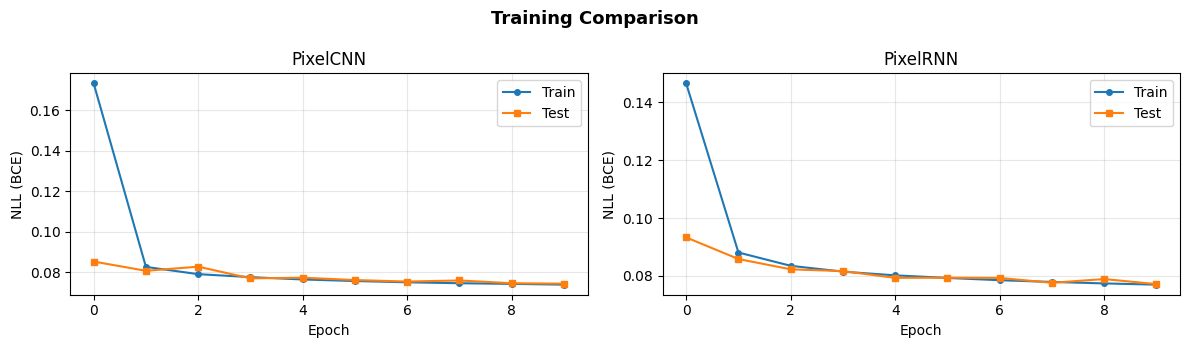


Final Test NLL ->  PixelCNN: 0.0742  |  PixelRNN: 0.0772


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(cnn_train_losses, label='Train', marker='o', markersize=4)
axes[0].plot(cnn_test_losses, label='Test', marker='s', markersize=4)
axes[0].set_title('PixelCNN'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL (BCE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rnn_train_losses, label='Train', marker='o', markersize=4)
axes[1].plot(rnn_test_losses, label='Test', marker='s', markersize=4)
axes[1].set_title('PixelRNN'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('NLL (BCE)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nFinal Test NLL ->  PixelCNN: {cnn_test_losses[-1]:.4f}  |  PixelRNN: {rnn_test_losses[-1]:.4f}")

---
## Part 5 : Generating Images - Sequential Sampling

### 5.1 The Generation Process

Unlike a VAE or GAN that produces the whole image in one forward pass, autoregressive models generate **one pixel at a time**:

1. Start with a blank (all-zeros) canvas.
2. For each pixel position $(r, c)$ in raster order:
   - Run the full model on the current canvas to get $\hat{p}_{r,c}$.
   - Sample $x_{r,c} \sim \text{Bernoulli}(\hat{p}_{r,c})$.
   - Write the sampled value into the canvas.
3. After $28 \times 28 = 784$ forward passes, the image is complete.

This is why autoregressive generation is slow, but each pixel decision is conditioned on all previous pixels, which can yield high quality.

In [ ]:
@torch.no_grad()
def generate_samples(model, n_samples=8, image_size=28):
    """
    Generate images pixel-by-pixel in raster order.
    Returns the completed samples and a list of intermediate snapshots.
    """
    model.eval()
    samples = torch.zeros(n_samples, 1, image_size, image_size).to(device)
    snapshots = []

    for r in range(image_size):
        for c in range(image_size):
            logits = model(samples)
            probs  = torch.sigmoid(logits[:, :, r, c])
            pixel  = torch.bernoulli(probs)
            samples[:, :, r, c] = pixel

            # Save snapshot at ~every 1/6th of the way through
            step = r * image_size + c
            if step % (image_size * image_size // 6) == 0:
                snapshots.append(samples[0, 0].cpu().clone())

    snapshots.append(samples[0, 0].cpu().clone())
    return samples.cpu(), snapshots


# Generate from both models
print("Generating from PixelCNN...")
t0 = time.time()
cnn_samples, cnn_snapshots = generate_samples(pixelcnn, n_samples=8)
print(f"Done in {time.time() - t0:.1f}s")

print("Generating from PixelRNN...")
t0 = time.time()
rnn_samples, rnn_snapshots = generate_samples(pixelrnn, n_samples=8)
print(f"Done in {time.time() - t0:.1f}s")

Generating from PixelCNN...
Done in 3.2s
Generating from PixelRNN...
Done in 22.1s


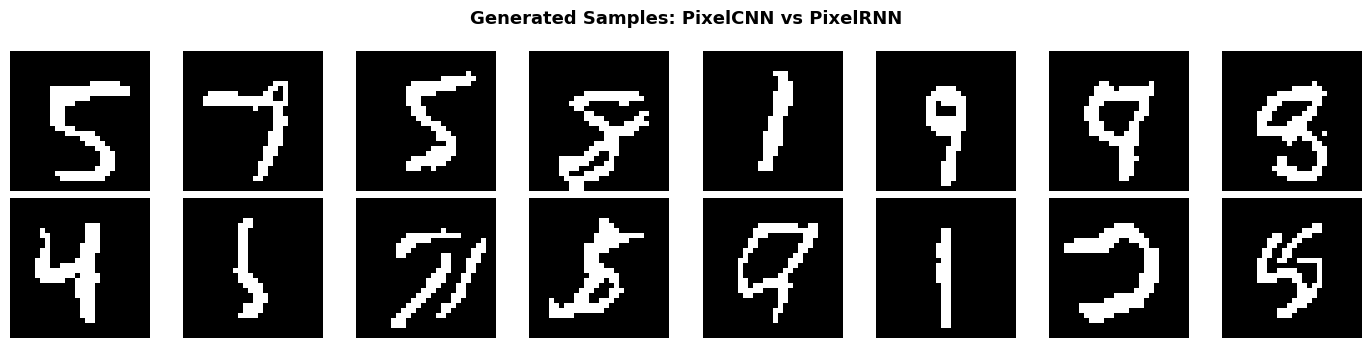

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i in range(8):
    axes[0, i].imshow(cnn_samples[i, 0], cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(rnn_samples[i, 0], cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('PixelCNN', fontsize=11, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('PixelRNN', fontsize=11, rotation=0, labelpad=50, va='center')
plt.suptitle('Generated Samples: PixelCNN vs PixelRNN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.2 Watching the Sequential Process

The snapshots below show how the image builds up row by row. Pixels in the top rows are decided first and constrain what appears below.

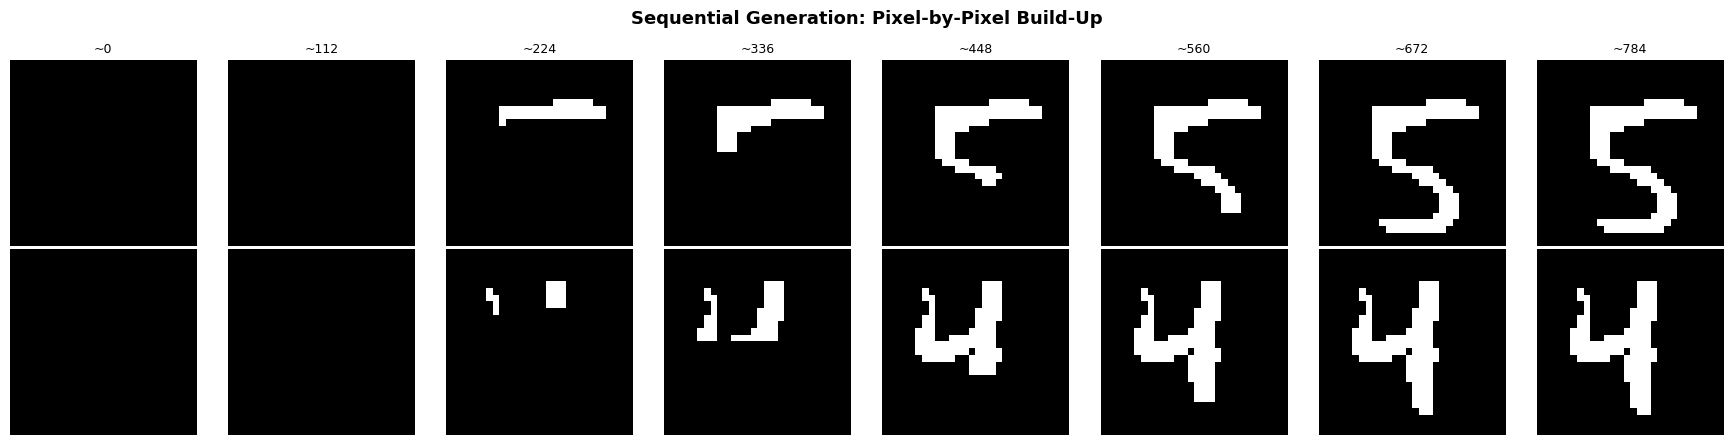

In [ ]:
fig, axes = plt.subplots(2, len(cnn_snapshots), figsize=(2.2 * len(cnn_snapshots), 4.5))

for i, (csnap, rsnap) in enumerate(zip(cnn_snapshots, rnn_snapshots)):
    step = int(i * (784 / (len(cnn_snapshots) - 1))) if i < len(cnn_snapshots) - 1 else 784

    axes[0, i].imshow(csnap, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'~{step}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(rsnap, cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('PixelCNN', fontsize=10, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('PixelRNN', fontsize=10, rotation=0, labelpad=50, va='center')
plt.suptitle('Sequential Generation: Pixel-by-Pixel Build-Up', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 6 : Image Completion

Autoregressive models can do something VAEs and GANs cannot do naturally: **complete a partially observed image**. We provide the top half of a real image and let the model sample the bottom half, one pixel at a time.

Completing with PixelCNN...
Completing with PixelRNN...


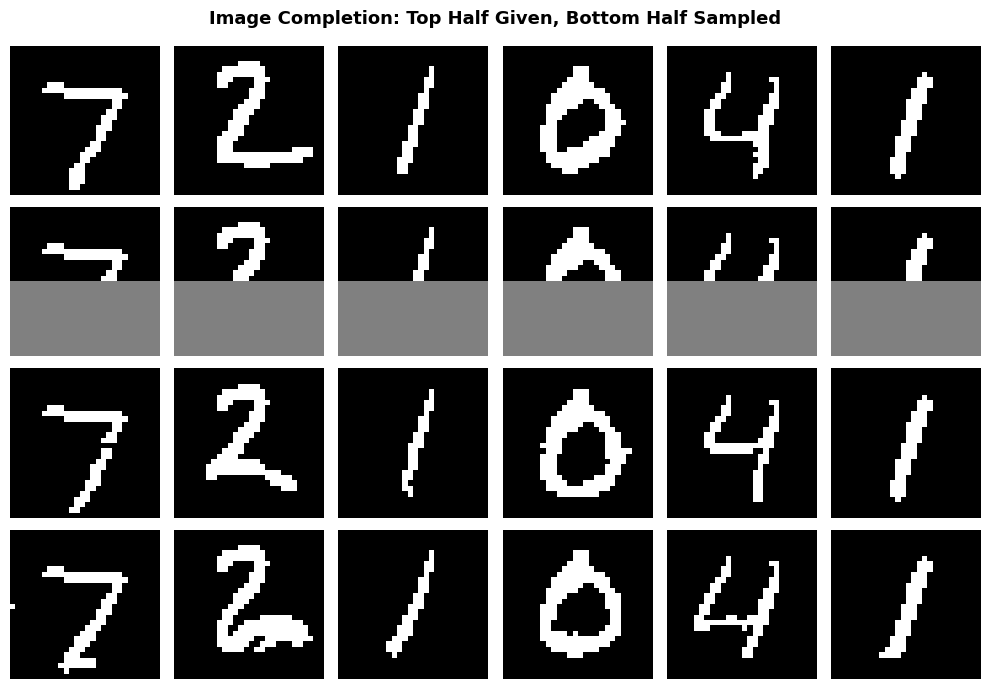

In [ ]:
@torch.no_grad()
def complete_images(model, images, n_given_rows=14):
    """
    Given the top `n_given_rows` of each image,
    sample the remaining rows autoregressively.
    """
    model.eval()
    samples = images.clone().to(device)
    _, _, H, W = samples.shape

    for r in range(n_given_rows, H):
        for c in range(W):
            logits = model(samples)
            probs  = torch.sigmoid(logits[:, :, r, c])
            samples[:, :, r, c] = torch.bernoulli(probs)

    return samples.cpu()


# Pick 6 test images
test_imgs, test_labels = next(iter(test_loader))
chosen = test_imgs[:6].to(device)

print("Completing with PixelCNN...")
cnn_completed = complete_images(pixelcnn, chosen, n_given_rows=14)
print("Completing with PixelRNN...")
rnn_completed = complete_images(pixelrnn, chosen, n_given_rows=14)

# Display: original | top-half-only | CNN completed | RNN completed
fig, axes = plt.subplots(4, 6, figsize=(10, 7))
row_labels = ['Original', 'Top half\n(given)', 'PixelCNN\ncompleted', 'PixelRNN\ncompleted']
for i in range(6):
    axes[0, i].imshow(chosen[i, 0].cpu(), cmap='gray'); axes[0, i].axis('off')

    half = chosen[i, 0].cpu().clone()
    half[14:, :] = 0.5
    axes[1, i].imshow(half, cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')

    axes[2, i].imshow(cnn_completed[i, 0], cmap='gray'); axes[2, i].axis('off')
    axes[3, i].imshow(rnn_completed[i, 0], cmap='gray'); axes[3, i].axis('off')

for j, label in enumerate(row_labels):
    axes[j, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=55, va='center')

plt.suptitle('Image Completion: Top Half Given, Bottom Half Sampled',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 7 : What Has the Model Learned?

Let's visualise the per-pixel probabilities $\hat{p}(x_i = 1 \mid x_{<i})$ predicted by both models on real test images. Bright = model is confident pixel is ON.

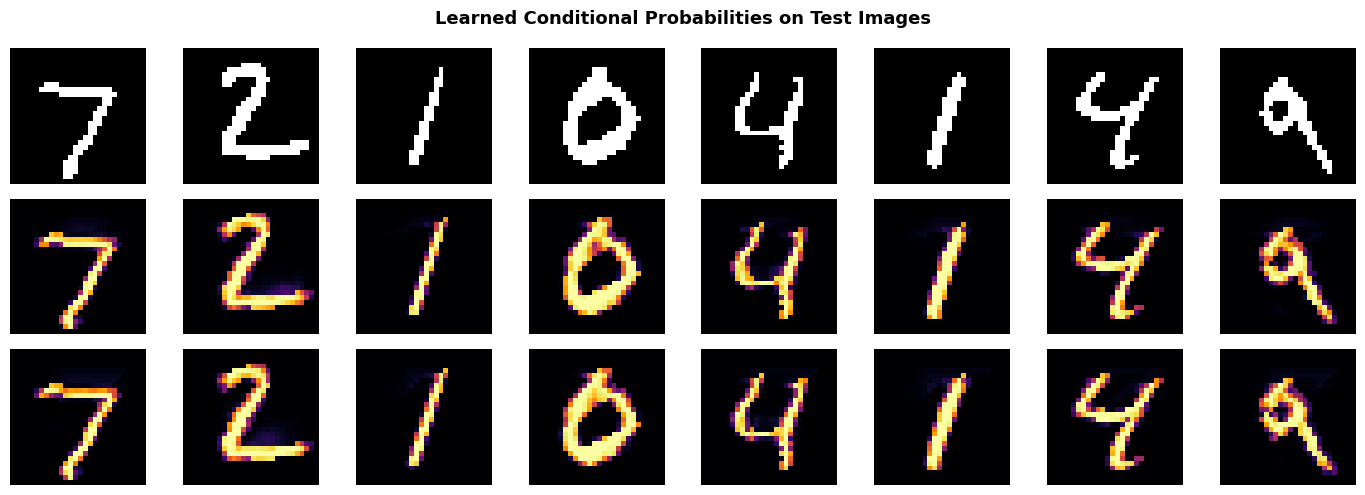

In [ ]:
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs[:8].to(device)

with torch.no_grad():
    cnn_logits = pixelcnn(test_imgs)
    rnn_logits = pixelrnn(test_imgs)
    cnn_probs  = torch.sigmoid(cnn_logits)
    rnn_probs  = torch.sigmoid(rnn_logits)

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for i in range(8):
    axes[0, i].imshow(test_imgs[i, 0].cpu(), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(cnn_probs[i, 0].cpu(), cmap='inferno', vmin=0, vmax=1)
    axes[1, i].axis('off')

    axes[2, i].imshow(rnn_probs[i, 0].cpu(), cmap='inferno', vmin=0, vmax=1)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Input', fontsize=10, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('PixelCNN\nP(x=1)', fontsize=10, rotation=0, labelpad=40, va='center')
axes[2, 0].set_ylabel('PixelRNN\nP(x=1)', fontsize=10, rotation=0, labelpad=40, va='center')

plt.suptitle('Learned Conditional Probabilities on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Summary: Autoregressive Models in the Generative Landscape

| | **VAE** | **GAN** | **PixelCNN / PixelRNN** |
|---|---|---|---|
| **Likelihood** | Lower bound (ELBO) | No likelihood | Exact log-likelihood |
| **Generation** | One-shot (decode $z$) | One-shot (generator forward pass) | Sequential, $O(n)$ passes for $n$ pixels |
| **Training** | Stable (single ELBO loss) | Tricky (adversarial balance) | Stable (teacher forcing with NLL) |
| **Sample quality** | Blurry | Sharp | Sharp but slow |
| **Conditional generation** | Encode-decode | Feed labels to G and D | Condition on class, previous pixels, or partial image |
| **Unique strength** | Smooth latent space | High visual fidelity | Exact density, principled completion |

**Key takeaway:** Autoregressive models trade generation speed for modelling rigour. They are the only models here that give you an exact, tractable probability for any image. This makes them especially valuable when you need calibrated likelihoods (anomaly detection, lossless compression, scientific modelling).

### Further Evolution

| Model | Key Improvement |
|---|---|
| **Gated PixelCNN** (van den Oord et al., 2016) | Gated activations + separate vertical/horizontal stacks fix the "blind spot" in the receptive field |
| **PixelCNN++** (Salimans et al., 2017) | Discretised logistic mixture likelihood, short-cut connections, improved training |
| **PixelSNAIL** (Chen et al., 2018) | Combines causal convolutions with self-attention for global context |
| **Image GPT** (Chen et al., 2020) | Applies GPT-style transformers to pixel sequences, bridging autoregressive image and language modelling |

---
## Part 8 : Exercises

**Receptive Field:**

1. **Effect of Network Depth on Generation Quality.**
   The demo uses `n_layers=7` for PixelCNN. Retrain a shallower model with `n_layers=3` (keep everything else identical).
   - Generate 8 samples from each model and display them side by side.
   - Compare the test NLL of both models. Which is lower (better)?
   - A shallower model has a smaller receptive field. How does this manifest in the generated samples? Look especially at long-range coherence: do digits maintain consistent structure from top to bottom?

   Hint: Just change `n_layers=3` in the `PixelCNN(...)` constructor and retrain.


**Sampling:**

2. **Temperature Sampling.**
   During generation we sample from $\text{Bernoulli}(\sigma(\text{logit}))$. We can sharpen or soften this by scaling the logit by a temperature $\tau$:

   $$p = \sigma(\text{logit} \;/ \;\tau)$$

   - $\tau = 1.0$: standard sampling (baseline)
   - $\tau < 1.0$: sharper, more deterministic (pushes probabilities toward 0 or 1)
   - $\tau > 1.0$: softer, more random

   Modify the `generate_samples` function to accept a `temperature` parameter. Generate 8 samples at $\tau \in \{0.5, 1.0, 1.5\}$ and display them. How does temperature affect the diversity and quality of samples?

   Hint: Change `probs = torch.sigmoid(logits[:, :, r, c])` to `probs = torch.sigmoid(logits[:, :, r, c] / temperature)`.


### Further Reading

| Topic | Resource |
|---|---|
| **PixelRNN/PixelCNN** (original paper) | [Pixel Recurrent Neural Networks](https://arxiv.org/abs/1601.06759) - van den Oord et al., 2016 |
| **Gated PixelCNN** | [Conditional Image Generation with PixelCNN Decoders](https://arxiv.org/abs/1606.05328) - van den Oord et al., 2016 |
| **PixelCNN++** | [PixelCNN++: Improving the PixelCNN with Discretized Logistic Mixture Likelihood](https://arxiv.org/abs/1701.05517) |
| **Survey of autoregressive models** | [Autoregressive Models in Deep Learning - A Brief Survey](https://eigenfoo.xyz/deep-autoregressive-models/) |

## **Please solve the exercises post this cell, take code from demo, make appropriate changes and execute them post this markdown cell**